Greyson Roy \
9\25\2026 \
Lab 5 - Orbital Mechanics Simulator

In [132]:
import numpy as np
import matplotlib.pyplot as plt

Part A — A Single Orbit with Velocity Verlet

1. The verlet step function is defined below
2. The acceleration function is defined below
3. The orbit is run with the given initial conditions below
4. The trajectory is closed, the requested plots are generated below
5. The starting point is apoapsis, we can see this from how the speed is less than the circular speed as this means it must have GPE than the orbital average.

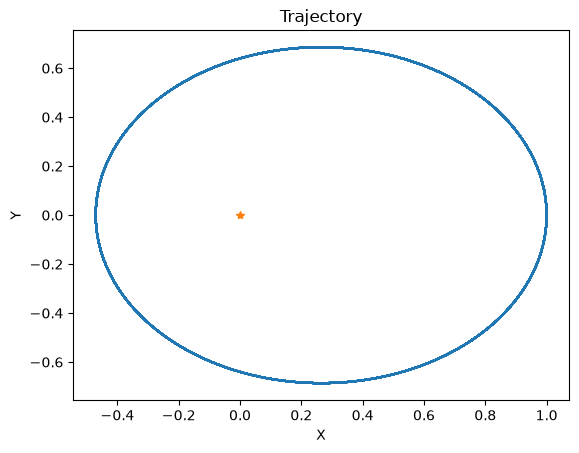

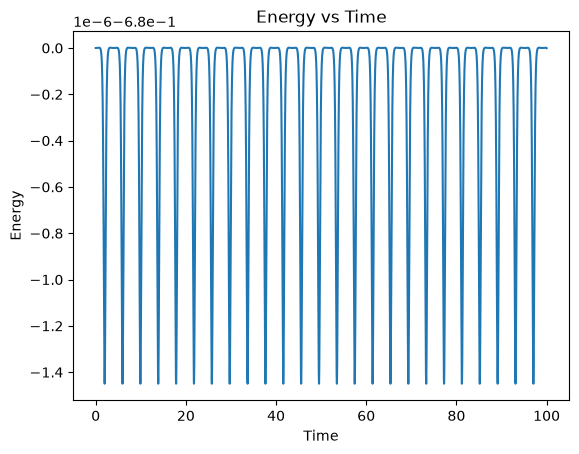

Text(0.5, 1.0, 'Energy vs Angular Momentum')

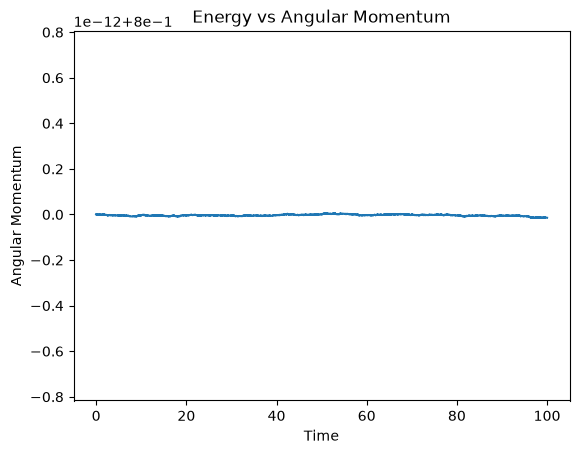

In [182]:
def verlet_step(r, v, a, dt, accel_func):
    r_new = r + v*dt + 0.5*a*dt**2
    a_new = accel_func(r_new)
    v_new = v + 0.5*(a+a_new)*dt
    return r_new, a_new, v_new

G = 1
M = 1

def accel(r, r2 = np.array([0,0]), m2=M):
    return -G*m2*(r-r2)/(np.linalg.norm(r-r2)**3)

def energy(r, v, G=1.0, M=1.0, m=1.0):
    ke = 0.5*m*np.dot(v,v)
    pe = -G*M*m/np.linalg.norm(r)
    return ke + pe

def angular_momentum(r, v, M=1.0, m=1.0):
    return m * (r[0]*v[1] - r[1]*v[0])

r = np.array([1, 0])
v = np.array([0, 0.8])
a = accel(r)
dt = 0.001
t = 0
t_list = [0]
r_list = [r.copy()]
E = energy(r, v)
E_list = [E]
L = angular_momentum(r, v)
L_list = [L]

while t < 100:
    t += dt
    r, a, v = verlet_step(r, v, a, dt, accel)
    E = energy(r, v)
    L = angular_momentum(r, v)
    t_list.append(t)
    r_list.append(r.copy())
    E_list.append(E)
    L_list.append(L)

r_list = np.array(r_list)
E_list = np.array(E_list)
plt.plot(r_list[:, 0], r_list[:, 1])
plt.plot(0, 0, '*', label='origin')
plt.title('Trajectory')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()
plt.plot(t_list, E_list)
plt.xlabel('Time')
plt.ylabel('Energy')
plt.title('Energy vs Time')
plt.show()
plt.plot(t_list, L_list)
plt.xlabel('Time')
plt.ylabel('Angular Momentum')
plt.title('Energy vs Angular Momentum')

Part B — The Integrator Showdown

1. The simulate function is below as described
2. All three runs are below as requested
3. The plot is below as requested

|                | Euler | Euler-Cromer | Verlet |
|----------------|--------------|---------------|---------------|
| Max $\lvert\Delta E/E_0\rvert$ | 0.061         |      0.00098     |       2.1E-6     |

5. The euler method trajectory spirals out since the euler method updates radius using the old velocity, artificially adding energy to the simulation. The verlet method is a symplectic integrator, which means it preserves the phas space of the system over time. This means energy error is bounded. We can see that although the euler-cromer and verlet methods are both symplectic, the verlet method is much more accurate.

In [134]:
M = 1

def simulate(method, dt, n_steps, r=np.array([1., 0.]), v=np.array([0., 0.8])):

    r = r.copy()
    v = v.copy()
    n = 0
    t = 0
    a = accel(r)
    t_list = [0]
    r_list = [r.copy()]
    E = energy(r, v)
    E_list = [E]
    L = angular_momentum(r, v)
    L_list = [L]

    while n < n_steps:

        n+=1
        t+=dt
        
        if method == 'euler':
            a = accel(r)
            r += v*dt
            v += a*dt

        if method == 'euler-cromer':
            a = accel(r)
            v += a*dt
            r += v*dt

        if method == 'verlet':
            r, a, v = verlet_step(r, v, a, dt, accel)

        E = energy(r, v)
        L = angular_momentum(r, v)
        t_list.append(t)
        r_list.append(r.copy())
        E_list.append(E)
        L_list.append(L)

    return t_list, r_list, E_list, L_list

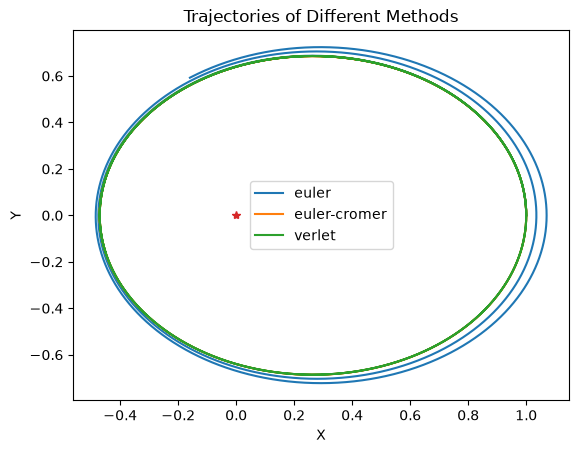

0.060716624740559985
0.0009763457220509055
2.1318638648521885e-06


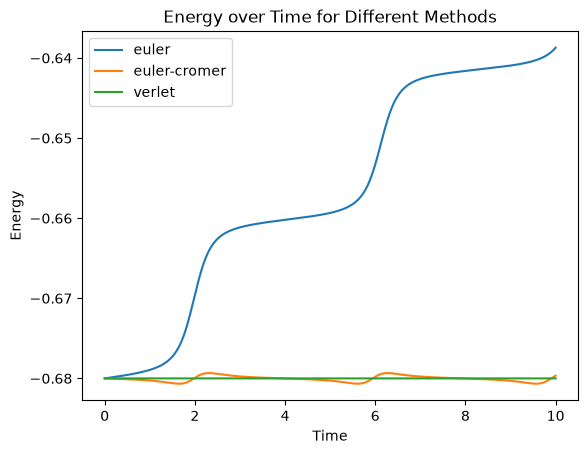

In [181]:
euler_t, euler_r, euler_E, euler_L = simulate('euler', 0.001, 10000)
cromer_t, cromer_r, cromer_E, cromer_L = simulate('euler-cromer', 0.001, 10000)
verlet_t, verlet_r, verlet_E, verlet_L = simulate('verlet', 0.001, 10000)
euler_r, euler_E, euler_L = np.array(euler_r), np.array(euler_E), np.array(euler_L)
cromer_r, cromer_E, cromer_L = np.array(cromer_r), np.array(cromer_E), np.array(cromer_L)
verlet_r, verlet_E, verlet_L = np.array(verlet_r), np.array(verlet_E), np.array(verlet_L)

plt.plot(euler_r[:,0],euler_r[:,1], label='euler')
plt.plot(cromer_r[:,0],cromer_r[:,1], label='euler-cromer')
plt.plot(verlet_r[:,0],verlet_r[:,1], label='verlet')
plt.plot(0,0,'*')
plt.title('Trajectories of Different Methods')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()
plt.plot(euler_t,euler_E, label='euler')
plt.plot(cromer_t,cromer_E, label='euler-cromer')
plt.plot(verlet_t,verlet_E, label='verlet')
plt.xlabel('Time')
plt.ylabel('Energy')
plt.title('Energy over Time for Different Methods')
plt.legend()

euler_error = max(abs((verlet_E[0] - euler_E)/verlet_E[0]))
cromer_error = max(abs((verlet_E[0] - cromer_E)/verlet_E[0]))
verlet_error = max(abs((verlet_E[0] - verlet_E)/verlet_E[0]))

print(euler_error)
print(cromer_error)
print(verlet_error)

Part C — Verify Kepler's Three Laws

1. We can see from the plot below that the bound orbit is a closed ellipse
2. The semi_major axis is estimated to be 0.157 units 
3. The plot of $T^2$ vs $a^3$ is below, the slope of the line is estimated to be within 0.1% of the expected $4\pi^2$
4. The measured slope is a very close match with theory. The greatest source of error depends on the choice of eps for the period approximation and dt for the simulation, the semi-major approximation depends on the choice of dt and is thus not the main source of error.

0.1570010869473522


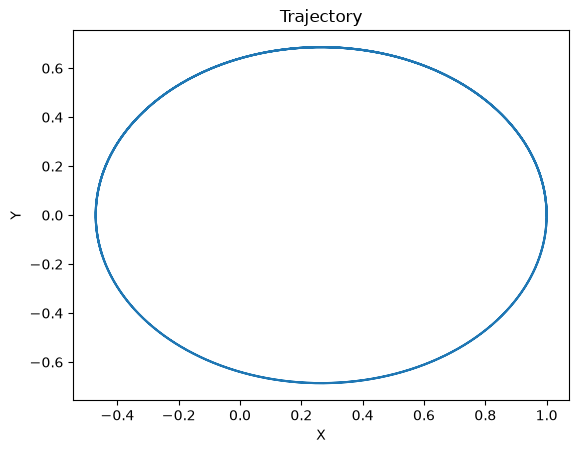

Text(0, 0.5, 'Area Covered per dt')

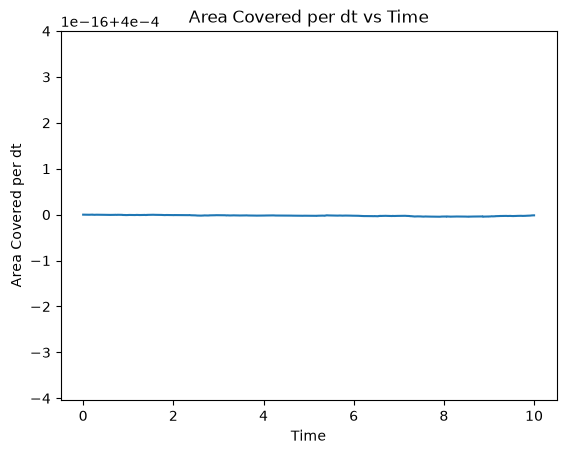

In [179]:
dt = 0.001
verlet_t, verlet_r, verlet_E, verlet_L = simulate('verlet', dt, 10000)
R = [np.linalg.norm(r) for r in verlet_r]
semi_major = (np.max(verlet_r)+np.min(verlet_r))/2
area = [0.5*(l)*dt for l in verlet_L] # subbing rxv for l/m, m = 1
verlet_r = np.array(verlet_r)
print(semi_major)
plt.plot(verlet_r[:,0], verlet_r[:,1])
plt.title('Trajectory')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()
plt.plot(verlet_t, area)
plt.title('Area Covered per dt vs Time')
plt.xlabel('Time')
plt.ylabel('Area Covered per dt')

39.45027407438362
0.0007128839422050337


Text(0, 0.5, 'a Cubed')

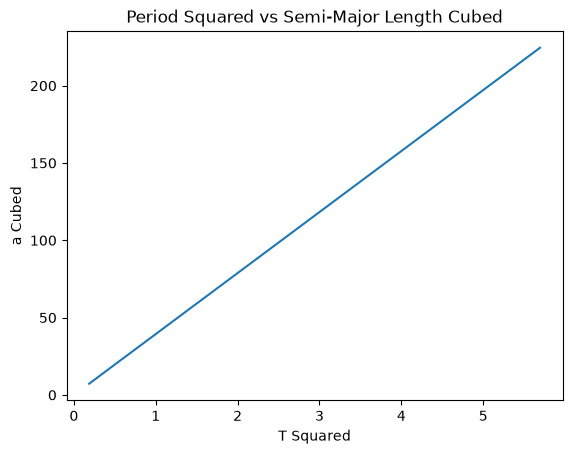

In [177]:
def period_approx(r, t, eps):
    n = 0
    start = True

    for n in range(len(r)):

        dist = np.linalg.norm(r[0] - r[n])

        if start and dist > eps:
            start = False
        if not start and dist < eps:
            return t[n]

t_1, r_1, E_1, L_1 = simulate('verlet', dt, 5000, v=np.array([0,0.5]))
t_2, r_2, E_2, L_2 = simulate('verlet', dt, 8000)
t_3, r_3, E_3, L_3 = simulate('verlet', dt, 10000, v=np.array([0,1.]))
t_4, r_4, E_4, L_4 = simulate('verlet', dt, 15000, v=np.array([0,1.2]))
r_1, r_2, r_3, r_4 = np.array(r_1), np.array(r_2), np.array(r_3), np.array(r_4)

semi_major = []
T_list = []
for r_n, t_n in [(r_1, t_1), (r_2, t_2), (r_3, t_3), (r_4, t_4)]:
    R = [np.linalg.norm(r) for r in r_n]
    semi_major.append((np.max(R)+np.min(R))/2)
    T_list.append(period_approx(r_n, t_n, 0.01))

a_cubed = [a**3 for a in semi_major]
T_squared = [T**2 for T in T_list]
slope, intercept = np.polyfit(a_cubed, T_squared, 1)
print(slope)
print(1-slope/(4*np.pi**2))
plt.plot(a_cubed, T_squared)
plt.title('Period Squared vs Semi-Major Length Cubed')
plt.xlabel('T Squared')
plt.ylabel('a Cubed')

Bonus - True Two-Body

The simutlation below is as requested, we can see from the plot that the center of mass moves in a straight line

In [150]:
def Two_Body_Sim(R_1, V_1, R_2, V_2, dt, n_steps, m_1 = 1, m_2 = 1):

    r_1 = R_1.copy()
    v_1 = V_1.copy()
    r_2 = R_2.copy()
    v_2 = V_2.copy()
    cm = (m_1*r_1+m_2*r_2)/(m_1+m_2)
    n = 0
    t = 0
    a_1 = accel(r_1, r2=r_2, m2=m_2)
    a_2 = accel(r_2, r2=r_1, m2=m_2)
    t_list = [0]
    r1_list = [r_1.copy()]
    r2_list = [r_2.copy()]
    cm_list = [cm.copy()]

    while n < n_steps:

        n+=1
        t+=dt

        r_1_new = r_1 + v_1*dt + 0.5*a_1*dt**2
        r_2_new = r_2 + v_2*dt + 0.5*a_2*dt**2

        a_1_new = accel(r_1_new, r2=r_2_new, m2=m_2)
        a_2_new = accel(r_2_new, r2=r_1_new, m2=m_1)

        v_1_new = v_1 + 0.5*(a_1 + a_1_new)*dt
        v_2_new = v_2 + 0.5*(a_2 + a_2_new)*dt

        r_1, r_2 = r_1_new, r_2_new
        v_1, v_2 = v_1_new, v_2_new
        a_1, a_2 = a_1_new, a_2_new

        cm = (m_1*r_1+m_2*r_2)/(m_1+m_2)
        
        t_list.append(t)
        r1_list.append(r_1.copy())
        r2_list.append(r_2.copy())
        cm_list.append(cm.copy())

    return t_list, r1_list, r2_list, cm_list

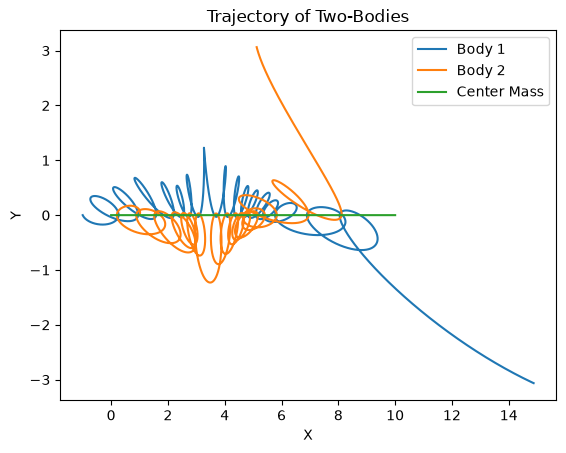

In [172]:
R_1 = np.array([-1, 0])
R_2 = np.array([1, 0])
V_1 = np.array([0.1, -0.12])
V_2 = np.array([0.1, 0.12])

t_list, r1_list, r2_list, cm_list = Two_Body_Sim(R_1, V_1, R_2, V_2, 0.01, 10000)
r1_list, r2_list, cm_list = np.array(r1_list), np.array(r2_list), np.array(cm_list)

plt.plot(r1_list[:,0], r1_list[:,1], label = 'Body 1')
plt.plot(r2_list[:,0], r2_list[:,1], label = 'Body 2')
plt.plot(cm_list[:,0], cm_list[:,1], label = 'Center Mass')
plt.title('Trajectory of Two-Bodies')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()